<div style="display:flex; justify-content:space-between; align-items:flex-start">

<div>
<span style="color:#3D0814; font-size:35px; font-weight:bold">
Limpieza de Datos de Riesgo Crediticio
</span>

<br>

<span style="color:#9A9B73; font-size:16px">
Erick Chicaiza · Credit Risk Data Cleaning
</span>
</div>

<div style="font-weight:bold; color:#3D0814; font-size:18px">
ECH
</div>

</div>

<hr>

> Preparación y limpieza del dataset para análisis y modelado de riesgo crediticio.

# <span style="color: #3D0814">0. Preparación de Datos</span>

---

> En esta sección se realizará una limpieza paso a paso del dataset, con el objetivo de prepararlo adecuadamente antes del modelado y mejorar la precisión del análisis.

## <span style="color: #442F38">0.1 Librerías</span>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## <span style="color: #442F38">0.2 Lecturas de datos</span>

In [2]:
df = pd.read_csv('..\credit-risk-loan-default-analysis\Loan_Default.csv')
df.head(3)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0


## <span style="color: #442F38">0.3 Información general del dataset</span>

In [3]:
df.info

<bound method DataFrame.info of             ID  year loan_limit             Gender approv_in_adv loan_type  \
0        24890  2019         cf  Sex Not Available         nopre     type1   
1        24891  2019         cf               Male         nopre     type2   
2        24892  2019         cf               Male           pre     type1   
3        24893  2019         cf               Male         nopre     type1   
4        24894  2019         cf              Joint           pre     type1   
...        ...   ...        ...                ...           ...       ...   
148665  173555  2019         cf  Sex Not Available         nopre     type1   
148666  173556  2019         cf               Male         nopre     type1   
148667  173557  2019         cf               Male         nopre     type1   
148668  173558  2019         cf             Female         nopre     type1   
148669  173559  2019         cf             Female         nopre     type1   

       loan_purpose Credit_Wort

## <span style="color: #442F38">0.4 Verificación de valores nulos</span>

In [4]:
print(df.isnull().any().any())

True


## <span style="color: #442F38">0.5 Cuantificación de valores nulos</span>

In [5]:
# cuantificar nulos
(df.isnull().sum()/len(df))*100

ID                            0.000000
year                          0.000000
loan_limit                    2.249277
Gender                        0.000000
approv_in_adv                 0.610749
loan_type                     0.000000
loan_purpose                  0.090133
Credit_Worthiness             0.000000
open_credit                   0.000000
business_or_commercial        0.000000
loan_amount                   0.000000
rate_of_interest             24.509989
Interest_rate_spread         24.644515
Upfront_charges              26.664425
term                          0.027578
Neg_ammortization             0.081388
interest_only                 0.000000
lump_sum_payment              0.000000
property_value               10.155378
construction_type             0.000000
occupancy_type                0.000000
Secured_by                    0.000000
total_units                   0.000000
income                        6.154571
credit_type                   0.000000
Credit_Score             

## <span style="color: #442F38">0.6 Vizualización de valores nulos</span>

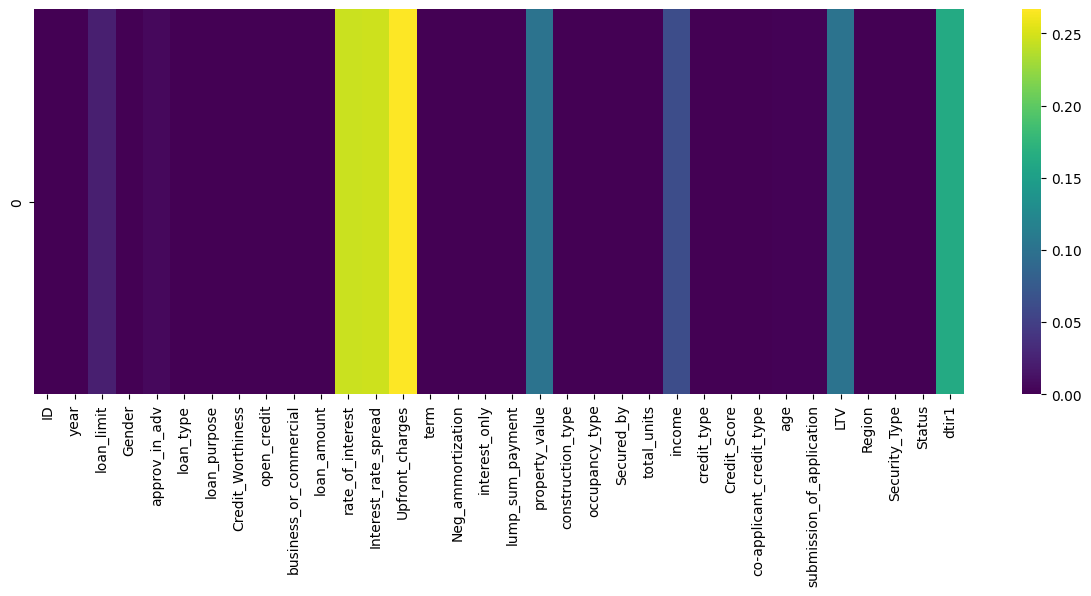

In [6]:
plt.figure(figsize=(15,5))
sns.heatmap(df.isnull().mean().to_frame().T, cmap="viridis", cbar=True)
plt.show()

## <span style="color:#442F38">0.7 Eliminación de columnas innecesarias</span>

In [7]:
df = df.drop(columns=["ID","year"])

# <span style="color: #3D0814">1. Imputación de datos</span>

---



In [8]:
# imputar datos para columnas > 20% nulos

df["rate_of_interest_missing"] = df["rate_of_interest"].isnull().astype(int)
df["rate_of_interest"] = df["rate_of_interest"].fillna(df["rate_of_interest"].median())

df["Interest_rate_spread_missing"] = df["Interest_rate_spread"].isnull().astype(int)
df["Interest_rate_spread"] = df["Interest_rate_spread"].fillna(df["Interest_rate_spread"].median())

df["Upfront_charges_missing"] = df["Upfront_charges"].isnull().astype(int)
df["Upfront_charges"] = df["Upfront_charges"].fillna(df["Upfront_charges"].median())

# imputar datos para columnas entre 5% y 20%
columnas = ["dtir1","property_value","LTV","income"]
for col in columnas:
    df[col] = df[col].fillna(df[col].median())

# verificación

df[["rate_of_interest","Interest_rate_spread","Upfront_charges"]].isnull().sum()

rate_of_interest        0
Interest_rate_spread    0
Upfront_charges         0
dtype: int64

# <span style="color: #3D0814">2. Revisión de duplicados</span>

---



In [9]:
df.duplicated().sum()

np.int64(0)

# <span style="color: #3D0814">3. Verificación de tipos</span>

---



In [10]:
df.dtypes

loan_limit                       object
Gender                           object
approv_in_adv                    object
loan_type                        object
loan_purpose                     object
Credit_Worthiness                object
open_credit                      object
business_or_commercial           object
loan_amount                       int64
rate_of_interest                float64
Interest_rate_spread            float64
Upfront_charges                 float64
term                            float64
Neg_ammortization                object
interest_only                    object
lump_sum_payment                 object
property_value                  float64
construction_type                object
occupancy_type                   object
Secured_by                       object
total_units                      object
income                          float64
credit_type                      object
Credit_Score                      int64
co-applicant_credit_type         object


In [11]:
df = pd.get_dummies(df, drop_first=True)
df.dtypes

loan_amount                            int64
rate_of_interest                     float64
Interest_rate_spread                 float64
Upfront_charges                      float64
term                                 float64
property_value                       float64
income                               float64
Credit_Score                           int64
LTV                                  float64
Status                                 int64
dtir1                                float64
rate_of_interest_missing               int64
Interest_rate_spread_missing           int64
Upfront_charges_missing                int64
loan_limit_ncf                          bool
Gender_Joint                            bool
Gender_Male                             bool
Gender_Sex Not Available                bool
approv_in_adv_pre                       bool
loan_type_type2                         bool
loan_type_type3                         bool
loan_purpose_p2                         bool
loan_purpo

# <span style="color: #3D0814">4. Estadística descriptiva</span>

---



In [12]:
df.describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1,rate_of_interest_missing,Interest_rate_spread_missing,Upfront_charges_missing
count,1.486700e+05,148670.000000,148670.000000,148670.000000,148629.000000,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000
mean,3.311177e+05,4.031879,0.429024,3057.397919,335.136582,4.897800e+05,6883.647811,699.789103,72.989111,0.246445,37.938508,0.245100,0.246445,0.266644
std,1.839093e+05,0.488348,0.445907,2797.972965,58.409084,3.420221e+05,6300.067060,115.875857,37.890714,0.430942,9.663417,0.430148,0.430942,0.442206
min,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000,0.000000,0.000000,0.000000
25%,1.965000e+05,3.750000,0.181500,1250.000000,360.000000,2.880000e+05,3840.000000,599.000000,63.297872,0.000000,33.000000,0.000000,0.000000,0.000000
50%,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000,0.000000,0.000000,0.000000
75%,4.365000e+05,4.250000,0.620000,3889.495000,360.000000,5.980000e+05,8280.000000,800.000000,84.722222,0.000000,44.000000,0.000000,0.000000,1.000000
max,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000,1.000000,1.000000,1.000000


# <span style="color: #3D0814">5. Detección de outliers</span>

---



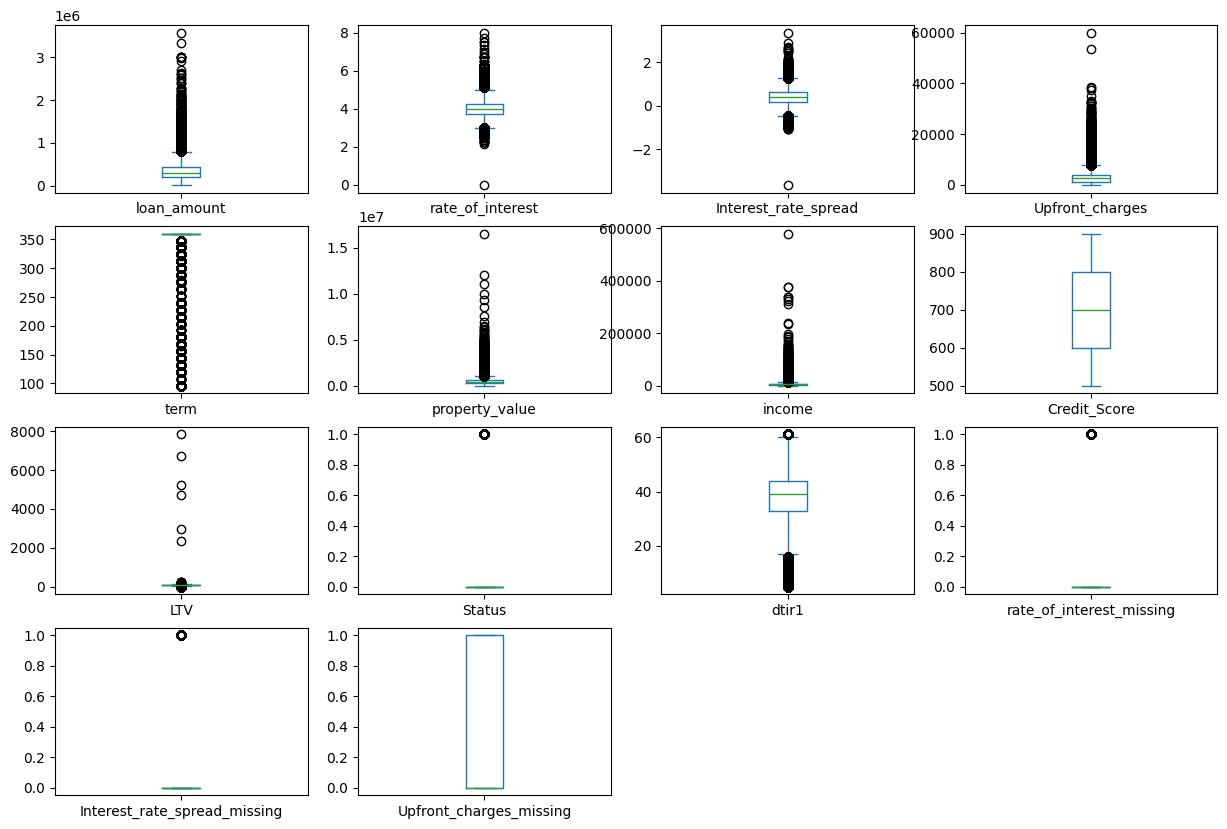

In [13]:
df.plot(kind="box", subplots=True, layout=(4,4), figsize=(15,10))
plt.show()

---

 > Nota: El boxplot global se ve afectado por las distintas escalas de las variables. Se utiliza únicamente como referencia visual general tras la limpieza de outliers.

---

# <span style="color: #3D0814">6. Limpieza de outliers</span>

---



In [14]:
df = df[df["income"]>0]
df = df[df["rate_of_interest"]>0]
df = df[df["LTV"]<200]
df = df[df["Interest_rate_spread"]>-1]

q99 = df["property_value"].quantile(0.99)
df = df[df["property_value"] < q99]

In [15]:
df.describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1,rate_of_interest_missing,Interest_rate_spread_missing,Upfront_charges_missing
count,1.458850e+05,145885.000000,145885.000000,145885.000000,145844.000000,1.458850e+05,145885.000000,145885.000000,145885.000000,145885.000000,145885.000000,145885.000000,145885.000000,145885.000000
mean,3.264550e+05,4.033184,0.431779,3059.606876,335.037814,4.701648e+05,6819.688796,699.816849,73.177182,0.240018,38.023841,0.238647,0.240018,0.259807
std,1.733573e+05,0.487728,0.447019,2779.769477,58.485994,2.639669e+05,5659.159720,115.883136,17.514679,0.427095,9.591100,0.426258,0.427095,0.438530
min,1.650000e+04,2.125000,-0.994500,0.000000,96.000000,1.800000e+04,60.000000,500.000000,3.083554,0.000000,5.000000,0.000000,0.000000,0.000000
25%,1.965000e+05,3.750000,0.181800,1250.000000,360.000000,2.880000e+05,3900.000000,599.000000,63.817481,0.000000,33.000000,0.000000,0.000000,0.000000
50%,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000,0.000000,0.000000,0.000000
75%,4.365000e+05,4.250000,0.628300,3924.900000,360.000000,5.880000e+05,8220.000000,800.000000,84.855769,0.000000,44.000000,0.000000,0.000000,1.000000
max,3.346500e+06,8.000000,3.357000,53485.780000,360.000000,1.748000e+06,374400.000000,900.000000,186.029412,1.000000,61.000000,1.000000,1.000000,1.000000


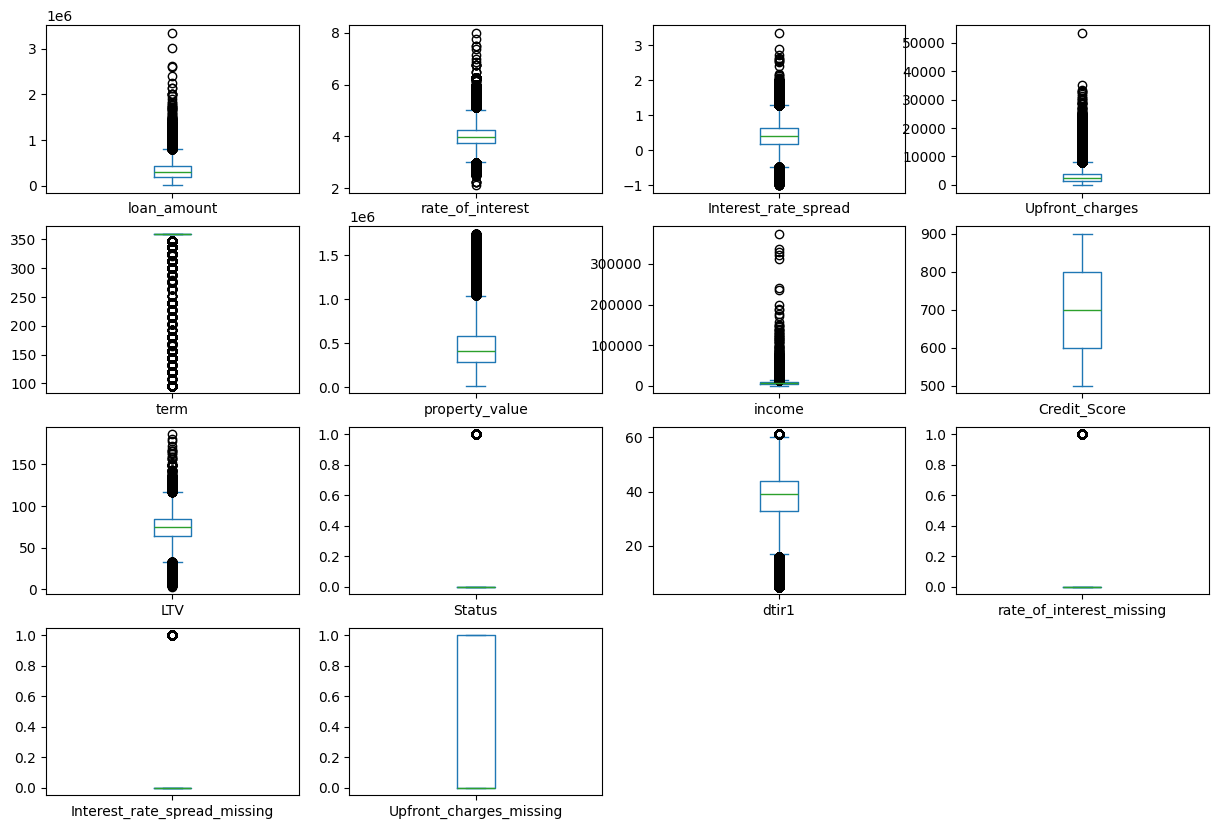

In [16]:
df.plot(kind="box", subplots=True, layout=(4,4), figsize=(15,10))
plt.show()

---

 > Nota: El boxplot global se ve afectado por las distintas escalas de las variables. Se utiliza únicamente como referencia visual general tras la limpieza de outliers.

---

In [17]:
df["Status"].value_counts(normalize=True)

Status
0    0.759982
1    0.240018
Name: proportion, dtype: float64

In [18]:
# exportamos el dataset limpio
df.to_csv("credit_risk_clean.csv", index=False)